In [1]:


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool, cv
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [4]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


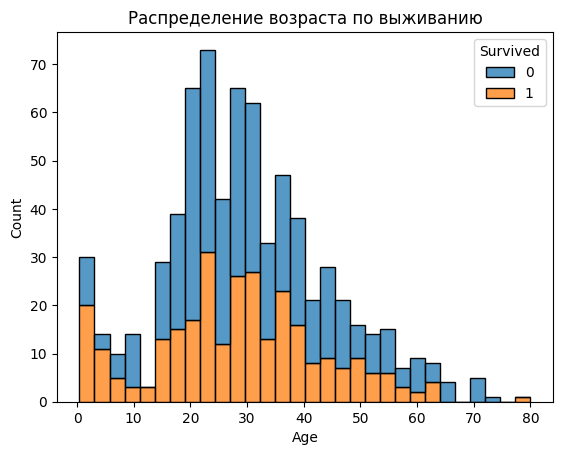

In [7]:
sns.histplot(data=train, x='Age', hue='Survived', bins=30, multiple='stack')
plt.title('Распределение возраста по выживанию')
plt.show()

### Missing values and Pipeline

In [8]:
test_ids = test['PassengerId']
X_train = train.drop(columns=['Survived'])
y_train = train['Survived']

In [9]:
def add_features(df):
    df = df.copy()
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major',
         'Rev','Sir','Jonkheer','Dona'], 'Rare')
    df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['Deck'] = df['Cabin'].str[0]
    return df

In [10]:
X_train = add_features(X_train)
test = add_features(test)

In [11]:
num_features = ['Age', 'Fare','Parch', 'SibSp']
cat_features = ['Pclass', 'Sex','Embarked','Title', 'IsAlone', 'Deck']
_cat_features = cat_features.copy()

Preprocess_XGB = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy="most_frequent")),
        ('encoder', OneHotEncoder(handle_unknown="ignore"))
    ]), cat_features)
])

Preprocess_LR = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
            ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy="most_frequent")),
        ('encoder', OneHotEncoder(handle_unknown="ignore"))
            ]), cat_features)
])

In [12]:
model_XGB = Pipeline([
    ('prep', Preprocess_XGB),
    ('clf', XGBClassifier(
        n_estimators=200,
        max_depth = 3,
        learning_rate = 0.05,
        subsample = 0.8,
        colsample_bytree = 0.8,
        min_child_weight=4, 
        reg_lambda=3, 
        gamma=0.4,
        random_state = 42
    )),
])

model_CB = CatBoostClassifier(
    iterations=200,
    depth=3,
    learning_rate=0.05,
    subsample=0.8,
    bootstrap_type='Bernoulli',
    rsm=0.8,
    min_data_in_leaf=4,
    l2_leaf_reg=3,
    cat_features=_cat_features,
    random_state=42,
    verbose=0,
)

model_LR = Pipeline([
    ('prep', Preprocess_LR),
    ('clf', LogisticRegression(
        penalty='l2',  
        C=1.0,
        solver='liblinear', 
        max_iter=1000,
        class_weight=None,
        random_state=42,
    )),
])


param_grid = {
    'clf__n_estimators': [200, 300, 500],
    'clf__max_depth': [3, 4, 5],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 1.0],
}

In [13]:
'''
grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print(grid.best_score_)
print(grid.best_params_)
'''

"\ngrid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)\ngrid.fit(X_train, y_train)\n\nprint(grid.best_score_)\nprint(grid.best_params_)\n"

#### 0.8440210909547423
#### {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.05,'clf__max_depth': 3, 'clf__n_estimators': 500, 'clf__subsample': 0.7}

In [14]:
X_train_CB = X_train.copy()
X_test_CB  = test.copy()
X_train_CB[_cat_features] = X_train_CB[_cat_features].fillna('missing')
X_test_CB[_cat_features]  = X_test_CB[_cat_features].fillna('missing')

In [15]:
scores_XGB = cross_val_score(model_XGB, X_train, y_train, cv=5, scoring='accuracy')
pool = Pool(X_train_CB[num_features+cat_features], y_train, cat_features=_cat_features)
params = {
    'iterations': 200, 'depth': 3, 'learning_rate': 0.05,
    'l2_leaf_reg': 3, 'min_data_in_leaf': 4,
    'loss_function': 'Logloss', 'eval_metric': 'Accuracy',
    'random_seed': 42, 'verbose': 0,
}
scores_CB = cv(pool, params, fold_count=5, stratified=True)
scores_LR  = cross_val_score(model_LR, X_train, y_train, cv=5, scoring='accuracy')
print(f"XGBoost: mean = {scores_XGB.mean()} std = {scores_XGB.std()}")
print(f"CatBoost: mean = {scores_CB['test-Accuracy-mean'].iloc[-1]}")
print(f"LogReg: mean = {scores_LR.mean()} std = {scores_LR.std()}")

Training on fold [0/5]

bestTest = 0.8044692737
bestIteration = 73

Training on fold [1/5]

bestTest = 0.8770949721
bestIteration = 105

Training on fold [2/5]

bestTest = 0.8651685393
bestIteration = 35

Training on fold [3/5]

bestTest = 0.7921348315
bestIteration = 75

Training on fold [4/5]

bestTest = 0.813559322
bestIteration = 109

XGBoost: mean = 0.8372857949908983 std = 0.017506528410108066
CatBoost: mean = 0.8147360066558219
LogReg: mean = 0.8271608813006088 std = 0.017542978499938175


In [16]:
model_LR.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'Parch',
                                                   'SibSp']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title', 'IsAlone',
                                                   'Deck'])])),
                ('clf',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [17]:

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': model_LR.predict(test),
})
submission.to_csv('submission.csv', index=False)
